# NNDL Week 1

**Name: Shashank Goel**
**Roll no: J011**
**SAP ID: 70092300008**
**Batch: B.Tech Data Science**

# Cat or Not-Cat — built live, in front of you

We are going to build and train a **neural network**, right now, on this laptop. No cloud, no GPU, no framework — one small file of numpy called `tinynet.py`.

It will not go well. That's the point. **Everything this course teaches is the story of why it doesn't go well — and how to fix it.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tinynet import Net, load_cat_data

X_train, y_train, X_test, y_test, train_imgs, test_imgs, classes = load_cat_data()

print(f"training images: {train_imgs.shape[0]}   ({int(y_train.sum())} cats)")
print(f"test images:     {test_imgs.shape[0]}   ({int(y_test.sum())} cats)")
print(f"each image:      {train_imgs.shape[1]}×{train_imgs.shape[2]} pixels × {train_imgs.shape[3]} colors")

training images: 209   (72 cats)
test images:     50   (33 cats)
each image:      64×64 pixels × 3 colors


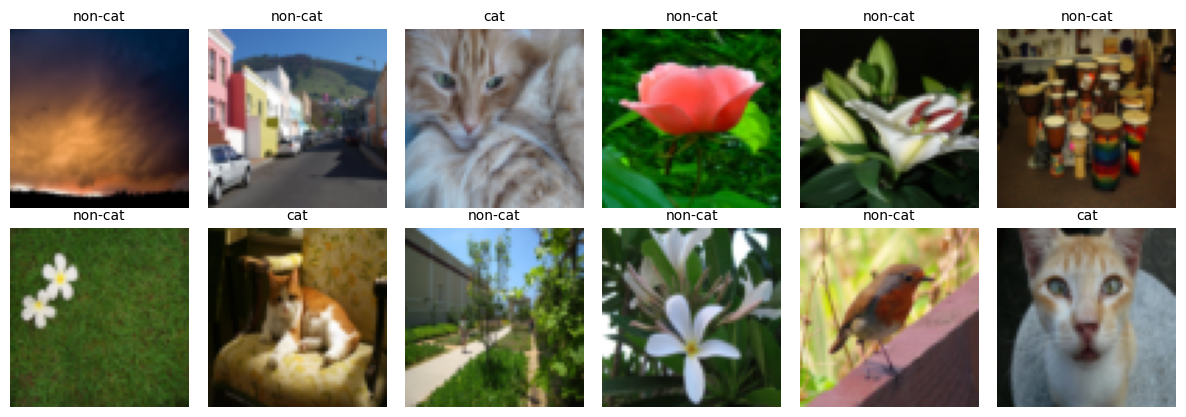

In [2]:
# meet the data
fig, axes = plt.subplots(2, 6, figsize=(12, 4.2))
for ax, i in zip(axes.flat, range(12)):
    ax.imshow(train_imgs[i])
    ax.set_title(classes[int(y_train[0, i])], fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

## To a computer, a cat is just numbers

64 × 64 pixels × 3 color channels = **12,288 numbers**. That's all the network will ever see.

The entire question of this course: *what do you do with 12,288 numbers to get one honest answer out?*

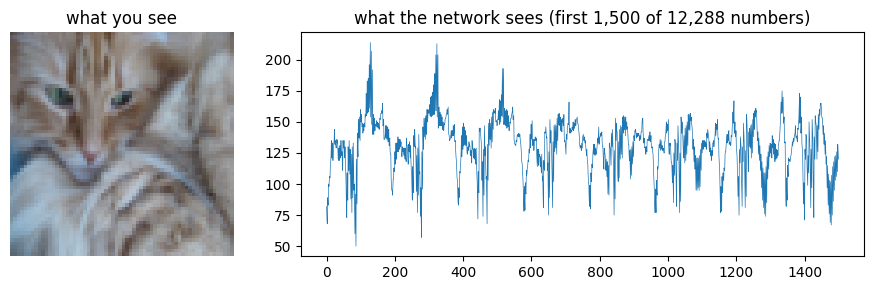

In [3]:
# take one cat and unroll it into a single column of numbers
one_cat = train_imgs[2]
unrolled = one_cat.reshape(-1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3), width_ratios=[1, 2.2])
ax1.imshow(one_cat); ax1.axis("off"); ax1.set_title("what you see")
ax2.plot(unrolled[:1500], lw=0.5)
ax2.set_title(f"what the network sees (first 1,500 of {unrolled.size:,} numbers)")
plt.tight_layout(); plt.show()

## Build the network. Train it. Live.

`layers=[12288, 16, 1]` means: 12,288 inputs → 16 neurons → 1 answer.

Watch the loss — that's the network's *embarrassment*, and gradient descent's whole job is to shrink it.

In [4]:
net = Net(layers=[12288, 16, 1])
net.train(X_train, y_train, X_test, y_test, epochs=2000, lr=0.05)

epoch     1 | loss 0.6498 | train acc 57.4% | test acc 54.0%
epoch   200 | loss 0.4507 | train acc 65.6% | test acc 34.0%
epoch   400 | loss 0.6151 | train acc 65.1% | test acc 76.0%
epoch   600 | loss 0.4878 | train acc 89.5% | test acc 72.0%
epoch   800 | loss 0.3207 | train acc 76.6% | test acc 62.0%
epoch  1000 | loss 0.3483 | train acc 89.0% | test acc 70.0%
epoch  1200 | loss 0.2636 | train acc 89.5% | test acc 66.0%
epoch  1400 | loss 0.5837 | train acc 71.3% | test acc 80.0%
epoch  1600 | loss 0.2502 | train acc 90.0% | test acc 64.0%
epoch  1800 | loss 0.2415 | train acc 90.0% | test acc 62.0%
epoch  2000 | loss 0.2402 | train acc 90.0% | test acc 64.0%


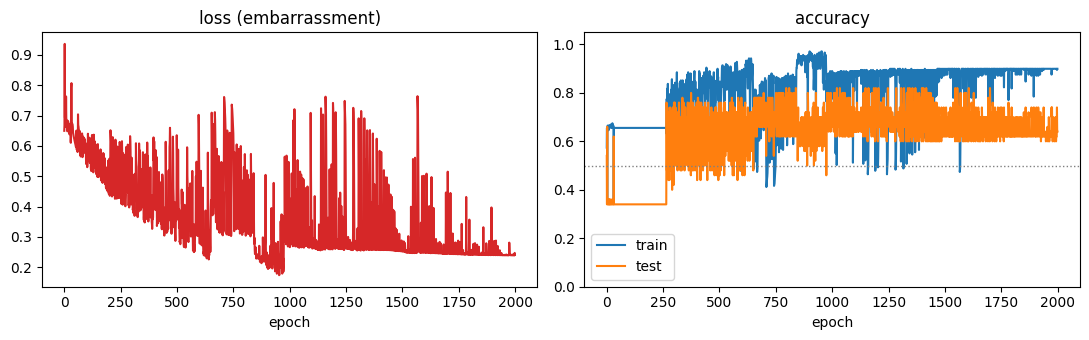


  TEST ACCURACY: 64%


In [5]:
net.plot()
print(f"\n{'='*46}\n  TEST ACCURACY: {net.accuracy(X_test, y_test):.0%}\n{'='*46}")

## Wait. Is that... good?

33 of the 50 test images are cats. A rock with the word **“cat”** written on it scores **66%**.

Our neural network — 196,000 learned parameters, 2,000 rounds of training — just lost to a rock.

And look at the curves: on the *training* images it's at ~90%. It's not failing to learn — it's **memorizing the study guide and flunking the exam**. Remember this sight; it has a name, and it gets a whole week later in the course.

*(Also: that loss curve is supposed to be "rolling downhill," and it looks like a seismograph. Put a pin in that too — it's a different disease, with its own week.)*

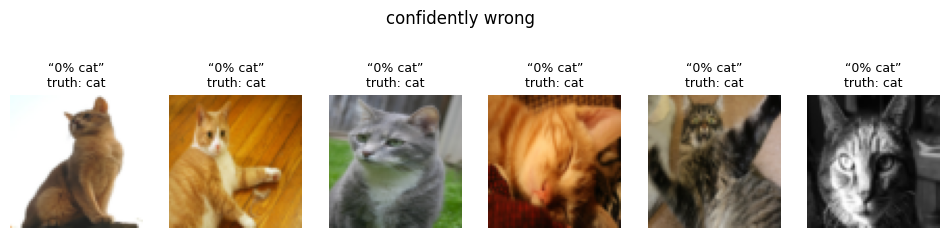

In [6]:
# the network's most CONFIDENT mistakes on the test set
proba = net.predict_proba(X_test)[0]
wrong = np.where((proba > 0.5).astype(int) != y_test[0])[0]
wrongest = wrong[np.argsort(-np.abs(proba[wrong] - 0.5))][:6]

fig, axes = plt.subplots(1, 6, figsize=(12, 2.6))
for ax, i in zip(axes.flat, wrongest):
    ax.imshow(test_imgs[i]); ax.axis("off")
    ax.set_title(f"“{proba[i]:.0%} cat”\ntruth: {classes[int(y_test[0, i])]}", fontsize=9)
plt.suptitle("confidently wrong", y=1.08)
plt.show()

---

# ⚔️ The Challenge

**Beat this network. You may change exactly ONE thing: the `my_hidden` list — the hidden layers.**

Each number is a layer; its value is how many neurons that layer gets:

- `[16]` — one hidden layer of 16 neurons (this morning's sad model)
- `[64]` — one wide layer of 64
- `[32, 32, 16, 4]` — **four** hidden layers, tapering
- as many layers, as wide or narrow, as you dare

The input (12,288 pixels) and the output (1 answer) are wired up for you and are off-limits. `epochs=2000`, `lr=0.05`, and the data are **frozen**. The seed is fixed — same layers, same score, no luck involved.

Post your best line to the leaderboard. Course-long bragging rights at stake.

*Spoiler you'll only appreciate in a few weeks: there is a ceiling, and you will hit it. And some perfectly reasonable-looking configurations will refuse to learn at all. Finding out **why** is the rest of this course.*

epoch     1 | loss 0.7114 | train acc 65.6% | test acc 34.0%
epoch   500 | loss 0.6333 | train acc 65.6% | test acc 34.0%
epoch  1000 | loss 0.1953 | train acc 99.0% | test acc 74.0%
epoch  1500 | loss 0.0022 | train acc 100.0% | test acc 80.0%
epoch  2000 | loss 0.0002 | train acc 100.0% | test acc 80.0%


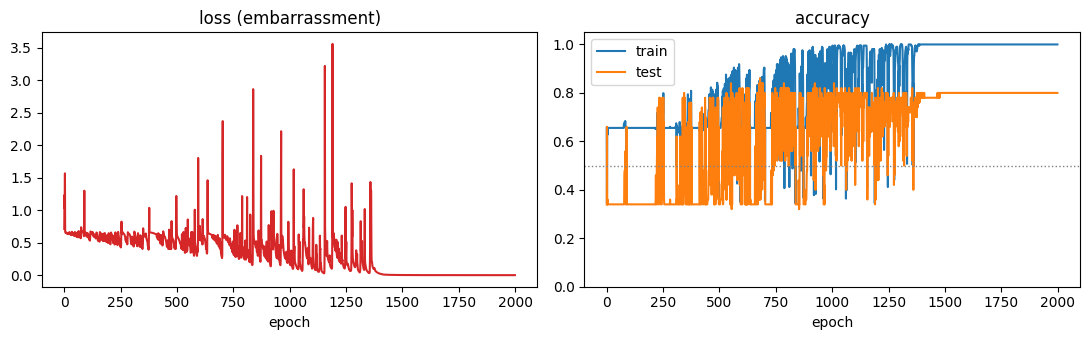


LEADERBOARD LINE →   [256, 128, 64, 32, 16, 4]   test acc: 80%


In [7]:
my_hidden = [256, 128, 64, 32, 16, 4]        

attempt = Net(layers=[12288] + my_hidden + [1])
attempt.train(X_train, y_train, X_test, y_test, epochs=2000, lr=0.05, log_every=500)
attempt.plot()
print(f"\nLEADERBOARD LINE →   {my_hidden}   test acc: {attempt.accuracy(X_test, y_test):.0%}")

### This ipynb is submitted by Shashank Goel